<a href="https://colab.research.google.com/github/Marriamshahjahan/information-extraction-svm/blob/main/nlp_machine_learning_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("juliangarratt/conll2003-dataset")

print("Path to dataset files:", path)

100%|██████████| 960k/960k [00:00<00:00, 117MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/juliangarratt/conll2003-dataset/versions/1


In [ ]:
import os

print(os.listdir(path))

['conll2003']


In [ ]:
import os

data_path = os.path.join(path, "conll2003")
print(os.listdir(data_path))

['eng.testa', 'eng.testb', 'eng.train']


In [ ]:
train_file = os.path.join(data_path, "eng.train")
valid_file = os.path.join(data_path, "eng.testa")
test_file  = os.path.join(data_path, "eng.testb")

In [ ]:
def load_conll(file_path):
    sentences = []
    pos_tags = []
    ner_tags = []

    words, pos, ner = [], [], []

    with open(file_path, "r") as f:
        for line in f:
            if line.startswith("-DOCSTART-") or line.strip() == "":
                if words:
                    sentences.append(words)
                    pos_tags.append(pos)
                    ner_tags.append(ner)
                    words, pos, ner = [], [], []
                continue

            parts = line.split()

            words.append(parts[0])
            pos.append(parts[1])
            ner.append(parts[-1])

    return sentences, pos_tags, ner_tags

In [ ]:
train_sentences, train_pos, train_ner = load_conll(train_file)

print(train_sentences[0])
print(train_pos[0])
print(train_ner[0])

['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
['NNP', 'VBZ', 'JJ', 'NN', 'TO', 'VB', 'JJ', 'NN', '.']
['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']


In [ ]:
def word2features(sentence, pos_tags, i):
    word = sentence[i]

    features = {
        'word': word,
        'lower': word.lower(),
        'is_upper': word.isupper(),
        'is_title': word.istitle(),
        'is_digit': word.isdigit(),
        'pos': pos_tags[i]
    }

    # Previous word
    if i > 0:
        prev_word = sentence[i-1]
        features.update({
            'prev_word': prev_word,
            'prev_lower': prev_word.lower(),
        })
    else:
        features['BOS'] = True

    # Next word
    if i < len(sentence)-1:
        next_word = sentence[i+1]
        features.update({
            'next_word': next_word,
            'next_lower': next_word.lower(),
        })
    else:
        features['EOS'] = True

    return features

In [ ]:
X = []
y = []

for sent, pos_tags, labels in zip(train_sentences, train_pos, train_ner):
    for i in range(len(sent)):
        X.append(word2features(sent, pos_tags, i))
        y.append(labels[i])

In [ ]:
from sklearn.feature_extraction import DictVectorizer

vectorizer = DictVectorizer(sparse=True)
X_vec = vectorizer.fit_transform(X)

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_vec, y)

LinearSVC()

In [ ]:
def predict_sentence(sentence, pos_tags):
    features = [word2features(sentence, pos_tags, i) for i in range(len(sentence))]
    features_vec = vectorizer.transform(features)

    preds = svm_model.predict(features_vec)

    return list(zip(sentence, preds))

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
import nltk

def process_input(sentence):
    tokens = nltk.word_tokenize(sentence)
    pos_tags = [tag for word, tag in nltk.pos_tag(tokens)]

    return tokens, pos_tags

In [ ]:
def predict_from_text(sentence):
    tokens, pos_tags = process_input(sentence)

    features = [word2features(tokens, pos_tags, i) for i in range(len(tokens))]
    features_vec = vectorizer.transform(features)

    preds = svm_model.predict(features_vec)

    return list(zip(tokens, preds))

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # ← IMPORTANT (new versions need this)
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [ ]:
import nltk

nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
sentence = "The Supreme Court of India is in New Delhi"

print(predict_from_text(sentence))

[('The', np.str_('O')), ('Supreme', np.str_('B-ORG')), ('Court', np.str_('I-ORG')), ('of', np.str_('I-ORG')), ('India', np.str_('B-LOC')), ('is', np.str_('O')), ('in', np.str_('O')), ('New', np.str_('B-LOC')), ('Delhi', np.str_('I-LOC'))]


In [ ]:
sentence = "The Supreme Court of India is in New Delhi"

print(predict_from_text(sentence))

[('The', np.str_('O')), ('Supreme', np.str_('B-ORG')), ('Court', np.str_('I-ORG')), ('of', np.str_('I-ORG')), ('India', np.str_('B-LOC')), ('is', np.str_('O')), ('in', np.str_('O')), ('New', np.str_('B-LOC')), ('Delhi', np.str_('I-LOC'))]


In [ ]:
def extract_information(sentence):
    tokens, pos_tags = process_input(sentence)

    features = [word2features(tokens, pos_tags, i) for i in range(len(tokens))]
    features_vec = vectorizer.transform(features)

    preds = svm_model.predict(features_vec)
    preds = [str(p) for p in preds]

    # Mapping FIX
    label_map = {
        "PER": "Person",
        "ORG": "Organization",
        "LOC": "Location",
        "MISC": "Misc"
    }

    entities = {
        "Person": [],
        "Organization": [],
        "Location": [],
        "Misc": []
    }

    current_entity = ""
    current_type = None

    for word, tag in zip(tokens, preds):

        if tag.startswith("B-"):
            if current_entity and current_type:
                entities[current_type].append(current_entity)

            entity_type = tag[2:]
            current_type = label_map.get(entity_type, None)

            current_entity = word

        elif tag.startswith("I-") and current_entity:
            current_entity += " " + word

        else:
            if current_entity and current_type:
                entities[current_type].append(current_entity)
                current_entity = ""
                current_type = None

    if current_entity and current_type:
        entities[current_type].append(current_entity)

    return entities

In [ ]:
def print_entities(entities):
    for key, values in entities.items():
        print(f"{key}:")
        if values:
            for v in values:
                print(f"  - {v}")
        else:
            print("  None")
        print()  # blank line

In [ ]:
result = extract_information("The Supreme Court of India is in New Delhi")

print_entities(result)

Person:
  None

Organization:
  - Supreme Court of

Location:
  - India
  - New Delhi

Misc:
  None



In [ ]:
result = extract_information("The Supreme Court of India delivered its verdict in New Delhi. Chief Justice D. Y. Chandrachud presided over the case. The decision was welcomed by legal experts across the country.")

print_entities(result)

Person:
  - Justice D. Y. Chandrachud

Organization:
  - Supreme Court of

Location:
  - India
  - New Delhi

Misc:
  None



In [ ]:
result = extract_information("Prime Minister Narendra Modi visited Kerala on Monday. He addressed a gathering in Kochi and discussed development projects. The event was organized by the Government of India.")

print_entities(result)

Person:
  - Narendra Modi

Organization:
  None

Location:
  - Kerala
  - Kochi
  - India

Misc:
  None



In [ ]:
result = extract_information("Sundar Pichai spoke at a conference in California. Google announced new AI features during the event.")

print_entities(result)

Person:
  - Sundar Pichai

Organization:
  - AI

Location:
  - California

Misc:
  None



In [ ]:
result = extract_information("Virat Kohli scored a century in the match held in Mumbai. The game was organized by the BCCI.")

print_entities(result)

Person:
  - Virat Kohli

Organization:
  - BCCI

Location:
  - Mumbai

Misc:
  None



In [ ]:
result = extract_information("Amazon is expanding its services in India. CEO Andy Jassy announced the plan in New York.")

print_entities(result)

Person:
  - Andy Jassy

Organization:
  None

Location:
  - Amazon
  - India
  - New York

Misc:
  None



In [ ]:
test_sentences, test_pos, test_ner = load_conll(test_file)

In [ ]:
X_test = []
y_test = []

for sent, pos_tags, labels in zip(test_sentences, test_pos, test_ner):
    for i in range(len(sent)):
        X_test.append(word2features(sent, pos_tags, i))
        y_test.append(labels[i])

In [ ]:
X_test_vec = vectorizer.transform(X_test)

In [ ]:
y_pred = svm_model.predict(X_test_vec)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       B-LOC       0.86      0.81      0.84      1668
      B-MISC       0.82      0.75      0.79       702
       B-ORG       0.81      0.73      0.77      1661
       B-PER       0.83      0.83      0.83      1617
       I-LOC       0.73      0.72      0.72       257
      I-MISC       0.65      0.66      0.65       216
       I-ORG       0.78      0.70      0.74       835
       I-PER       0.81      0.93      0.86      1156
           O       0.98      0.99      0.99     38323

    accuracy                           0.96     46435
   macro avg       0.81      0.79      0.80     46435
weighted avg       0.95      0.96      0.95     46435



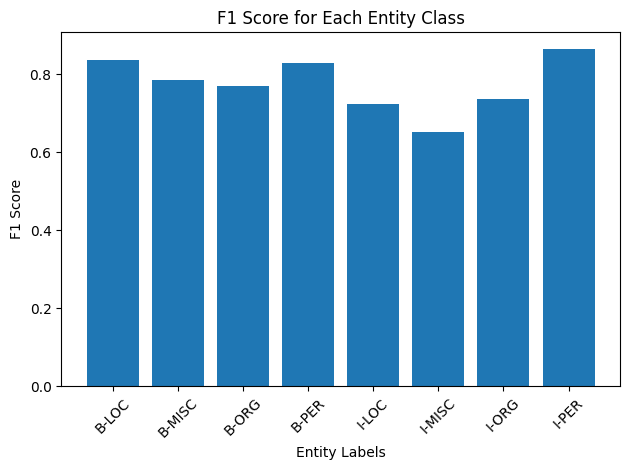

In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Step 1: Generate report
report = classification_report(y_test, y_pred, output_dict=True)

# Step 2: Extract entity labels (remove unwanted)
labels = []
f1_scores = []

for key in report:
    if key not in ["O", "accuracy", "macro avg", "weighted avg"]:
        labels.append(key)
        f1_scores.append(report[key]["f1-score"])

# Step 3: Plot
plt.figure()
plt.bar(labels, f1_scores)

plt.title("F1 Score for Each Entity Class")
plt.xlabel("Entity Labels")
plt.ylabel("F1 Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import joblib
import os

save_path = "/content/drive/MyDrive/"

# Create folder if not exists
os.makedirs(save_path, exist_ok=True)

# Save files
joblib.dump(svm_model, save_path + "svm_ner_model.pkl")
joblib.dump(vectorizer, save_path + "vectorizer.pkl")

print("Model saved to Google Drive ✅")

Model saved to Google Drive ✅
